 # **Credit Risk Analysis**

# Import libraries






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

# Accessing Google Drive Files in Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Financial Loan Dataset

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/financial_loan_dataset_wi.csv'
df = pd.read_csv(file_path)
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2/11/2021,9/13/2021,4/13/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,12/14/2021,1/15/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,1/5/2021,12/12/2021,1/9/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2/25/2021,12/12/2021,3/12/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,12/14/2021,1/15/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


# Dataset Shape (Rows and Columns)

In [ ]:
df.shape

(38576, 24)

# Check Missing Values in Dataset

In [ ]:
df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,1438
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


# Replace Missing Values with 'Unknown'

In [ ]:
df['emp_title'] = df['emp_title'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,0
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


# Check Data Types of Columns

In [ ]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,object
last_credit_pull_date,object
last_payment_date,object


# Convert DataType

In [ ]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'])
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'])
df['next_payment_date'] = pd.to_datetime(df['next_payment_date'])

In [ ]:
df['id'] = df['id'].astype(str)
df['member_id'] = df['member_id'].astype(str)

In [ ]:
df.dtypes

,0
id,object
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


# Dataset Information Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  object        
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              38576 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  object        
 13  p

# Count of Unique Values per Column

In [ ]:
df.nunique()

,0
id,38576
address_state,50
application_type,1
emp_length,11
emp_title,28526
grade,7
home_ownership,5
issue_date,65
last_credit_pull_date,107
last_payment_date,102


# List of Dataset Columns

In [ ]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

# Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

# Load Selected Columns from Dataset

In [ ]:
df_specific_cols= pd.read_csv(file_path, usecols=['address_state', 'emp_length','grade', 'home_ownership','loan_status',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income','dti', 'installment', 'int_rate', 'loan_amount',
       'total_acc','total_payment'])

# Dataset Numerical Description

In [ ]:
df_specific_cols.describe()

,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


# Get Unique Values in Column

In [ ]:
from enum import unique
df_specific_cols['grade'].unique()

array(['C', 'E', 'B', 'A', 'D', 'F', 'G'], dtype=object)

In [ ]:
df_specific_cols['sub_grade'].unique()

array(['C4', 'E1', 'C5', 'B2', 'A1', 'C3', 'C2', 'A4', 'A5', 'B5', 'B4',
       'B3', 'B1', 'D1', 'A2', 'A3', 'D4', 'D2', 'C1', 'D3', 'E3', 'F1',
       'E2', 'E5', 'D5', 'E4', 'F2', 'G3', 'F3', 'G1', 'F4', 'G4', 'G2',
       'F5', 'G5'], dtype=object)

# Number of Unique Values in Column

In [ ]:
df_specific_cols['grade'].nunique()

7

In [ ]:
df_specific_cols['sub_grade'].nunique()

35

# Count of Unique Values in Column

In [ ]:
df_specific_cols['grade'].value_counts()

,count
grade,
B,11674
A,9689
C,7904
D,5182
E,2786
F,1028
G,313


In [ ]:
df_specific_cols['sub_grade'].value_counts()

,count
sub_grade,
B3,2834
A4,2803
A5,2654
B5,2644
B4,2455
C1,2089
B2,1990
C2,1972
B1,1751


# Get Random Sample of Date

In [ ]:
df.sample(8)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
35266,548918,OH,INDIVIDUAL,10+ years,Charles Schwab,C,RENT,2021-07-10,2021-09-15,2021-03-13,...,C3,60 months,Verified,45000.0,0.2429,372.13,0.1398,16000,21,20650
10588,844358,KS,INDIVIDUAL,4 years,Genesis Health Clubs,A,RENT,2021-08-11,2021-06-14,2021-06-14,...,A4,36 months,Not Verified,28800.0,0.2050,217.72,0.0749,7000,19,7828
29178,549319,FL,INDIVIDUAL,10+ years,plumbers and pipefitters local 630,A,RENT,2021-07-10,2021-06-13,2021-01-13,...,A4,36 months,Source Verified,93000.0,0.0957,186.67,0.0751,6000,12,5486
28877,348410,IL,INDIVIDUAL,3 years,American Audio,A,RENT,2021-05-08,2021-06-10,2021-07-10,...,A3,36 months,Not Verified,160000.0,0.0998,235.03,0.0800,7500,42,8089
21288,643359,FL,INDIVIDUAL,8 years,LARGO MEDICAL CENTER--INDIAN ROCKS CAMPUS,B,RENT,2021-01-11,2021-05-16,2021-08-11,...,B5,60 months,Source Verified,54996.0,0.2498,389.93,0.1036,18200,25,19257
29856,852430,NY,INDIVIDUAL,1 year,East River Medical Imaging,B,RENT,2021-08-11,2021-02-16,2021-04-14,...,B3,36 months,Verified,64000.0,0.0932,425.55,0.1099,13000,13,15308
17574,411425,AL,INDIVIDUAL,10+ years,nicholsr industrial sales,D,MORTGAGE,2021-06-09,2021-06-12,2021-06-12,...,D2,36 months,Verified,60000.0,0.0368,343.83,0.1442,10000,21,12390
27850,831199,CA,INDIVIDUAL,8 years,SALINAS VALLEY FORD,E,MORTGAGE,2021-08-11,2021-05-16,2021-05-16,...,E2,60 months,Source Verified,85000.0,0.1763,512.13,0.1839,20000,28,29216


# Statistical Summary of Categorical Features

In [ ]:
df_specific_cols.describe(include=object)

,address_state,emp_length,grade,home_ownership,loan_status,purpose,sub_grade,term,verification_status
count,38576,38576,38576,38576,38576,38576,38576,38576,38576
unique,50,11,7,5,3,14,35,2,3
top,CA,10+ years,B,RENT,Fully Paid,Debt consolidation,B3,36 months,Not Verified
freq,6894,8870,11674,18439,32145,18214,2834,28237,16464


# Filter Data by Condition (Home Ownership = RENT)

In [ ]:
df_specific_cols_filter = df_specific_cols.loc[df_specific_cols['home_ownership']=='RENT']

In [ ]:
df_specific_cols_filter.head()

,address_state,emp_length,grade,home_ownership,loan_status,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,< 1 year,C,RENT,Charged Off,car,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,9 years,E,RENT,Fully Paid,car,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,4 years,C,RENT,Charged Off,car,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
5,CA,3 years,C,RENT,Fully Paid,car,C3,36 months,Not Verified,28000.0,0.1260,275.96,0.1465,8000,11,8637
11,CA,3 years,B,RENT,Charged Off,car,B4,36 months,Not Verified,75000.0,0.2288,374.26,0.1242,11200,13,4225


# View Last Rows of Dataset

In [ ]:
df_specific_cols.tail( )

,address_state,emp_length,grade,home_ownership,loan_status,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,NJ,< 1 year,C,MORTGAGE,Current,wedding,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,NY,8 years,C,RENT,Current,wedding,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,CA,5 years,D,RENT,Current,wedding,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,NY,5 years,D,RENT,Current,wedding,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,NY,4 years,F,RENT,Current,wedding,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


# Total Loan Applications

In [ ]:
total_loan_application=df['id'].count()
print("Total Loan Applications:", total_loan_application)

Total Loan Applications: 38576


# Box Plot - Annual Income by Loan Grade

/tmp/ipykernel_3289/4183488797.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y='annual_income',


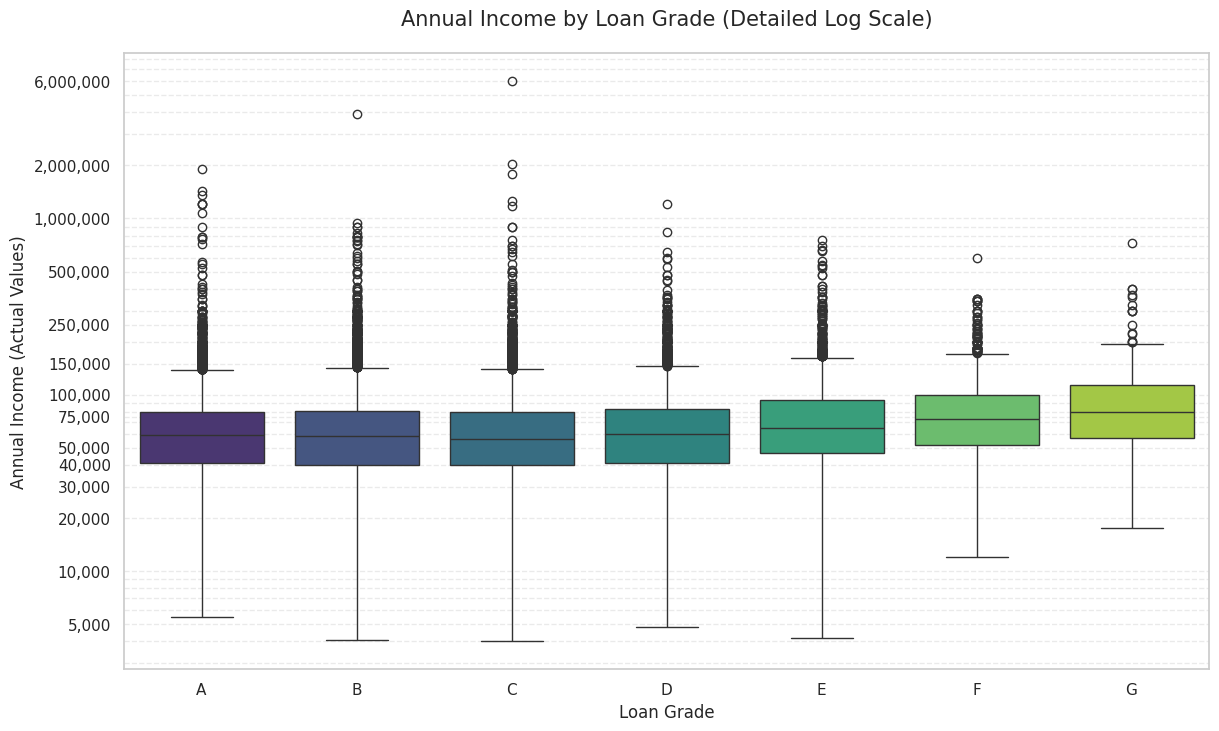

In [ ]:
from matplotlib.ticker import StrMethodFormatter

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

sns.boxplot(data=df, x='grade', y='annual_income',
            order=sorted(df['grade'].unique()),
            palette="viridis")

plt.yscale('log')

ax = plt.gca()
ticks = [5000, 10000, 20000, 30000, 40000, 50000, 75000, 100000, 150000, 250000, 500000, 1000000, 2000000, 6000000]
ax.set_yticks(ticks)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title('Annual Income by Loan Grade (Detailed Log Scale)', fontsize=15, pad=20)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Annual Income (Actual Values)', fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.4, axis='y')
plt.show()

# Box Plot - Debt-to-Income (DTI) Ratio by Loan Grade

/tmp/ipykernel_3289/1235447720.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y='dti',


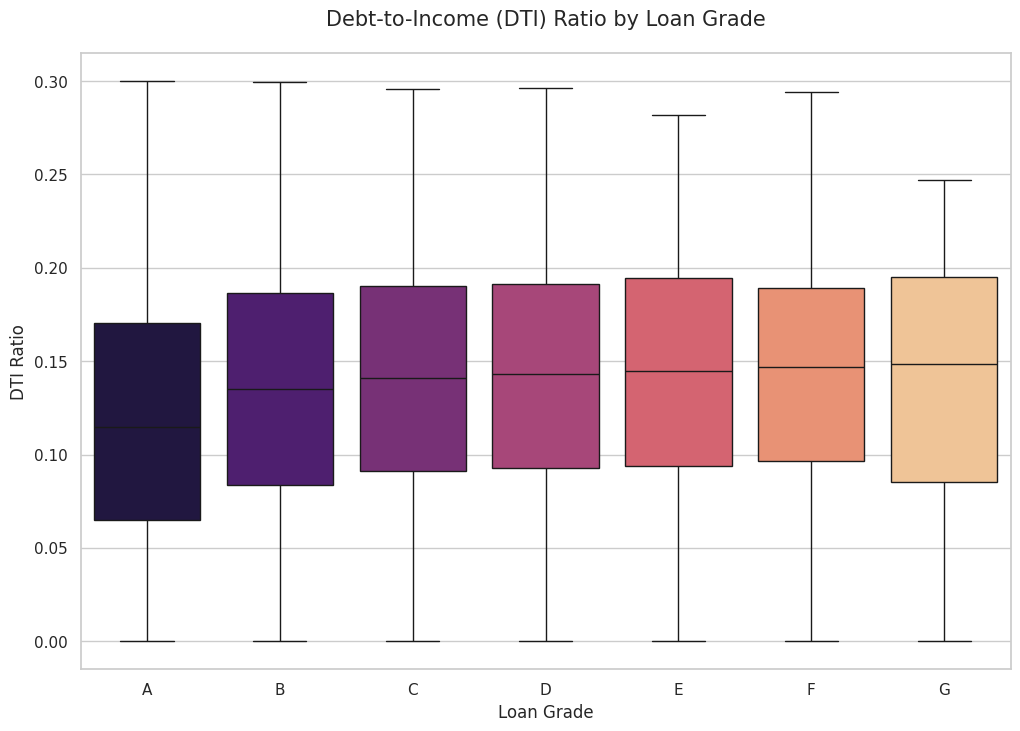

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.boxplot(data=df, x='grade', y='dti',
            order=sorted(df['grade'].unique()),
            palette="magma")

plt.title('Debt-to-Income (DTI) Ratio by Loan Grade', fontsize=15, pad=20)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('DTI Ratio', fontsize=12)
plt.show()

# Stacked Bar Chart for Home Ownership & Emp Length by Grade

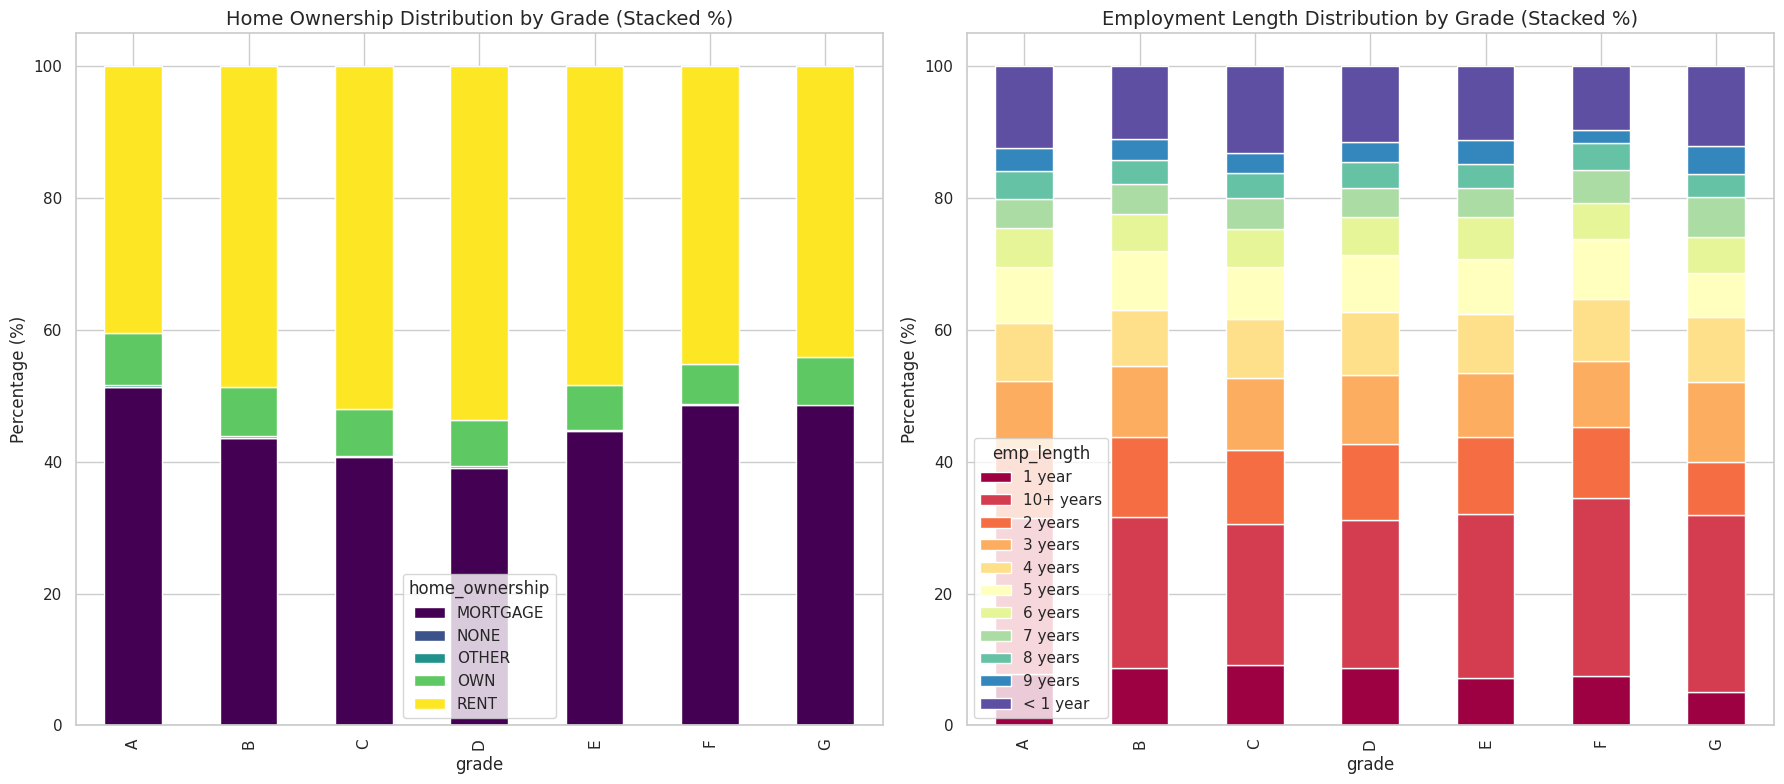

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 3. Stacked Bar Chart لملكية السكن (Home Ownership)
home_grade = pd.crosstab(df['grade'], df['home_ownership'], normalize='index') * 100
home_grade.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Home Ownership Distribution by Grade (Stacked %)', fontsize=14)
axes[0].set_ylabel('Percentage (%)')

# 4. Stacked Bar Chart لسنوات الخبرة (Emp Length)
emp_grade = pd.crosstab(df['grade'], df['emp_length'], normalize='index') * 100
emp_grade.plot(kind='bar', stacked=True, ax=axes[1], colormap='Spectral')
axes[1].set_title('Employment Length Distribution by Grade (Stacked %)', fontsize=14)
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

# Horizontal Bar Chart - Distribution of Loan Purposes by Number of Borrowers

/tmp/ipykernel_3289/3338761943.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




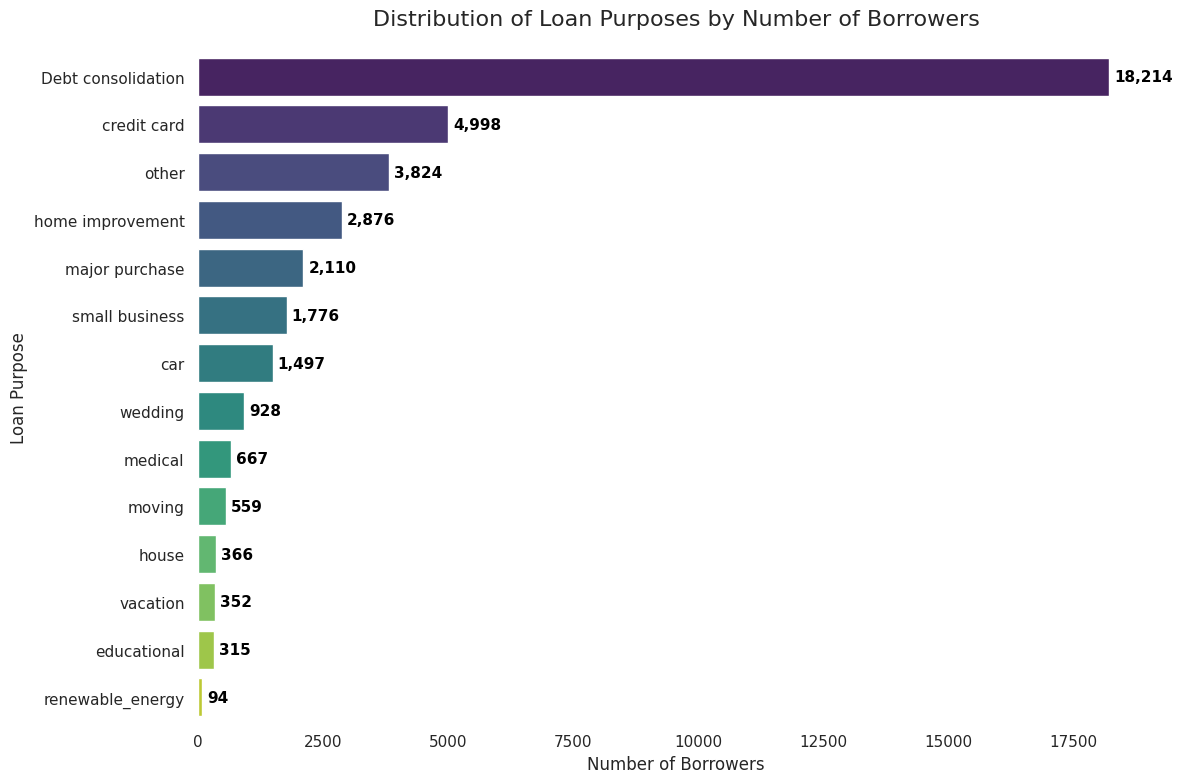

In [ ]:
purpose_counts = df['purpose'].value_counts().reset_index()
purpose_counts.columns = ['purpose', 'count']

plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

plot = sns.barplot(data=purpose_counts, x='count', y='purpose', palette='viridis')

for i, count in enumerate(purpose_counts['count']):
    plt.text(count + 100, i, f'{count:,}', va='center', fontsize=11, color='black', fontweight='bold')

plt.title('Distribution of Loan Purposes by Number of Borrowers', fontsize=16, pad=20)
plt.xlabel('Number of Borrowers', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Bar Chart - Average Interest Rate by Loan Grade

/tmp/ipykernel_3289/3386658683.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




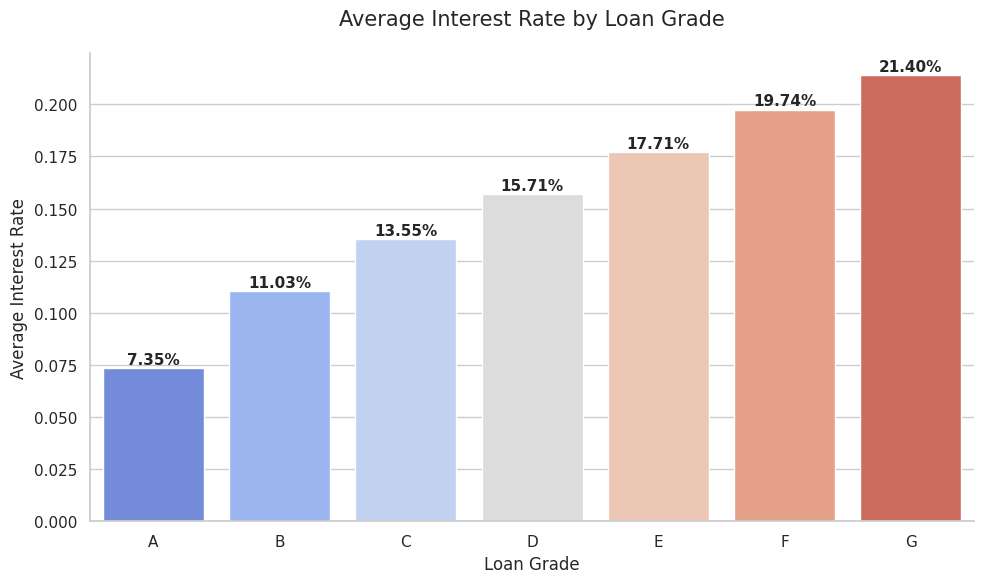

In [ ]:
grade_interest = df.groupby('grade')['int_rate'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=grade_interest, x='grade', y='int_rate', palette='coolwarm')

for i, row in grade_interest.iterrows():
    ax.text(i, row['int_rate'] + 0.002, f"{row['int_rate']:.2%}",
            ha='center', fontweight='bold', fontsize=11)

plt.title('Average Interest Rate by Loan Grade', fontsize=15, pad=20)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Average Interest Rate', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# Stacked Bar Chart - Loan Status Breakdown by Grade

<Figure size 1200x700 with 0 Axes>

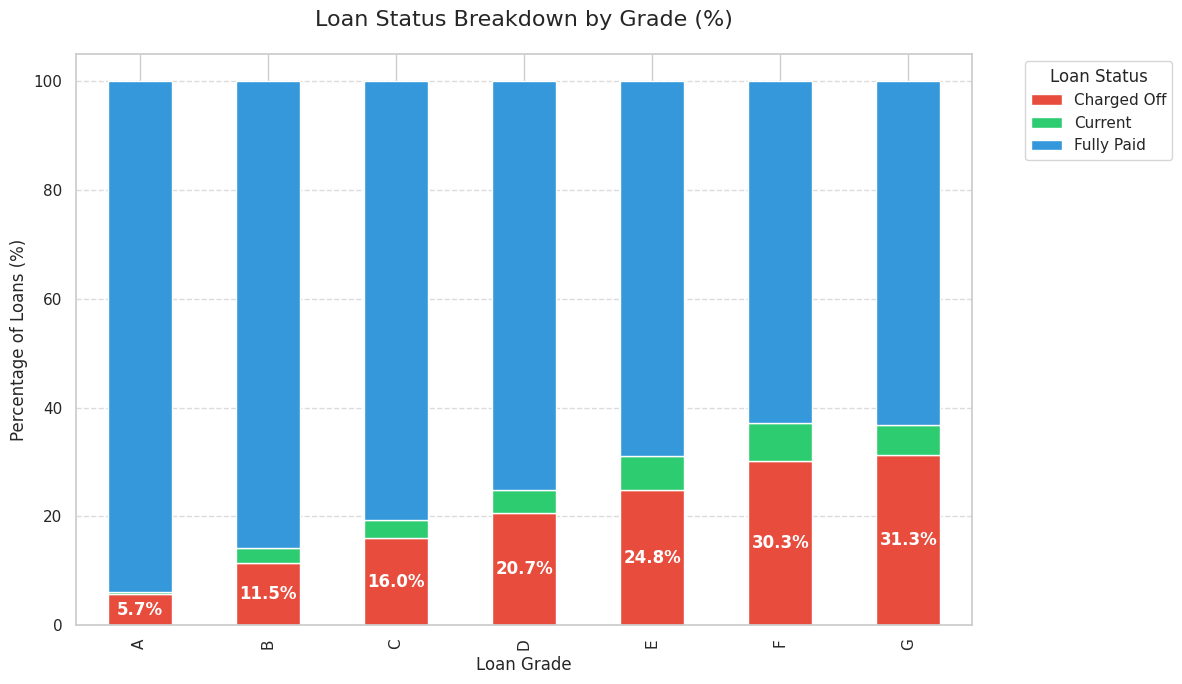

In [ ]:
loan_grade_pct = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
plt.figure(figsize=(12, 7))

colors = ['#e74c3c', '#2ecc71', '#3498db']
ax = loan_grade_pct.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors)

plt.title('Loan Status Breakdown by Grade (%)', fontsize=16, pad=20)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Percentage of Loans (%)', fontsize=12)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (idx, row) in enumerate(loan_grade_pct.iterrows()):
    charged_off_val = row['Charged Off']
    plt.text(i, charged_off_val / 2, f'{charged_off_val:.1f}%',
             ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Box Plot - Relationship Between Annual Income and Loan Status

/tmp/ipykernel_3289/2012420555.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




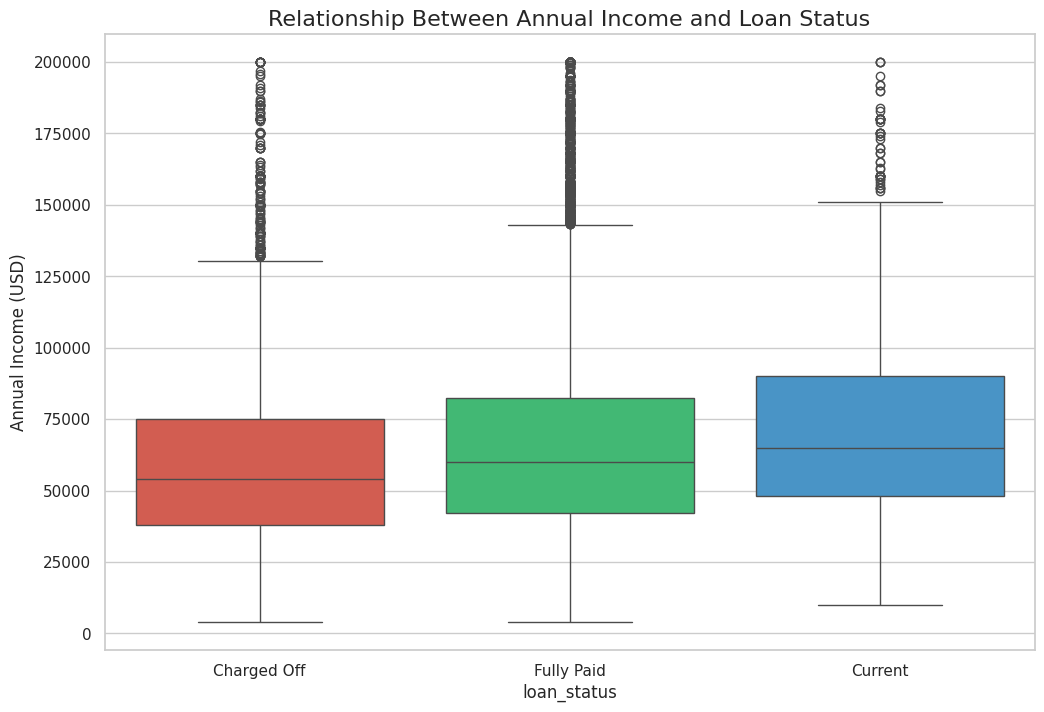

In [ ]:
df_filtered = df[df['annual_income'] <= 200000]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_filtered, x='loan_status', y='annual_income',
            palette={'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c', 'Current': '#3498db'})

plt.title('Relationship Between Annual Income and Loan Status', fontsize=16)
plt.ylabel('Annual Income (USD)')
plt.show()

# Horizontal Bar Chart - Charged Off Rate by Loan Purpose

/tmp/ipykernel_3289/200070542.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




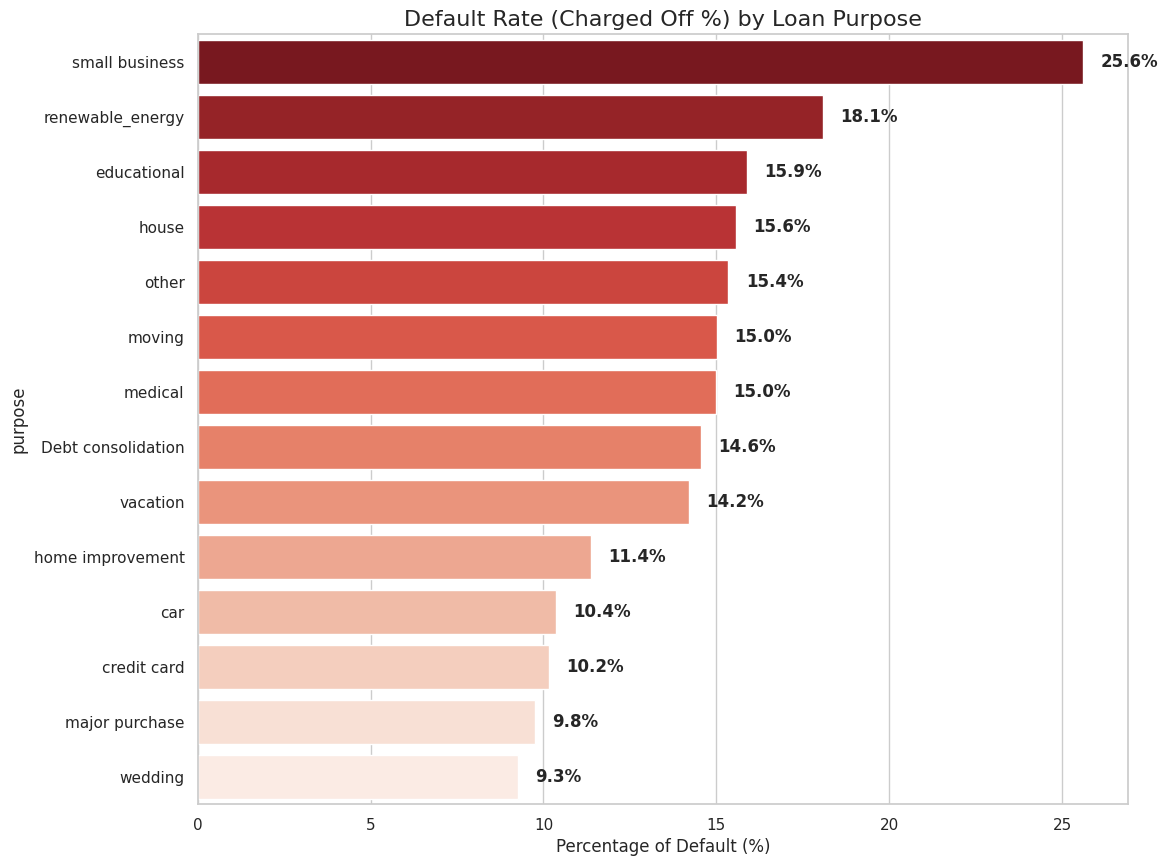

In [ ]:
purpose_status = pd.crosstab(df['purpose'], df['loan_status'], normalize='index') * 100
purpose_default = purpose_status['Charged Off'].sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))
sns.barplot(data=purpose_default, x='Charged Off', y='purpose', palette='Reds_r')

for i, val in enumerate(purpose_default['Charged Off']):
    plt.text(val + 0.5, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.title('Charged Off Rate by Loan Purpose', fontsize=16)
plt.xlabel('Percentage of Default (%)')
plt.show()

# Pie Chart - Loan Status Distribution

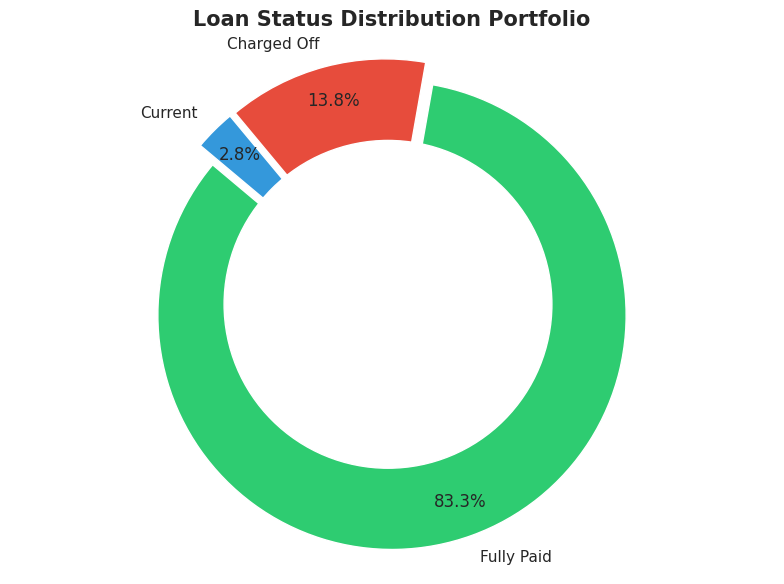

In [ ]:
status_counts = df['loan_status'].value_counts()

labels = status_counts.index
sizes = status_counts.values
colors = ['#2ecc71', '#e74c3c', '#3498db']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, pctdistance=0.85, explode=explode)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Loan Status Distribution', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Bar Plot - Comparing loan amounts versus refunds

/tmp/ipykernel_3289/281632109.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




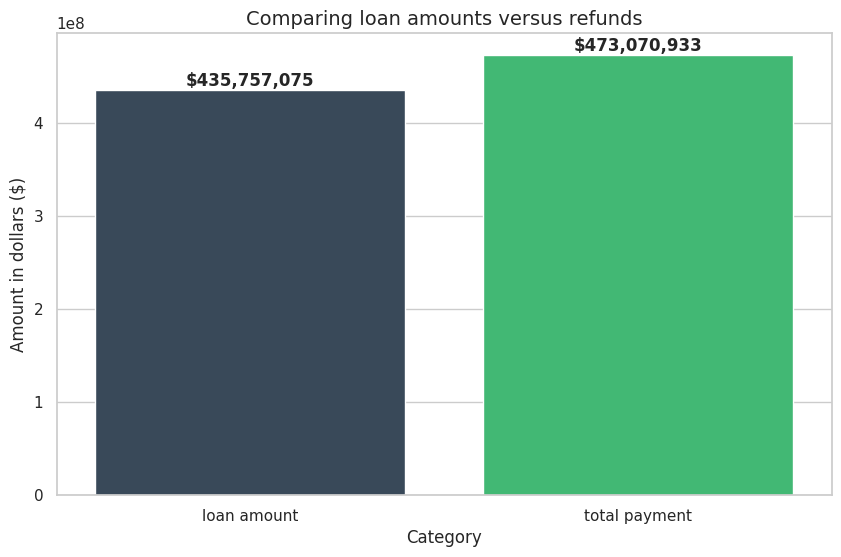

In [ ]:
#الرسمة  لمعرفة صافي الربح
total_loaned = df['loan_amount'].sum()
total_recovered = df['total_payment'].sum()

summary_df = pd.DataFrame({
    'Category': ['loan amount', 'total payment'],
    'Amount': [total_loaned, total_recovered]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary_df, x='Category', y='Amount', palette=['#34495e', '#2ecc71'])

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.title('Comparing loan amounts versus refunds', fontsize=14)
plt.ylabel('Amount in dollars ($)')
plt.show()

# Bar Blot - Average Annual Income Comparison

/tmp/ipykernel_3289/2830952355.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




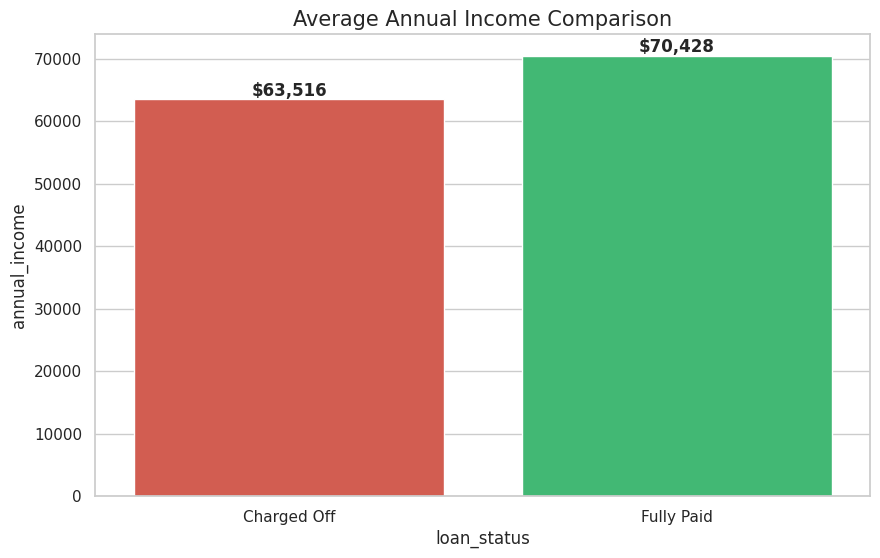

In [ ]:
filtered_df = df[df['loan_status'].isin(['Charged Off', 'Fully Paid'])]
avg_income = filtered_df.groupby('loan_status')['annual_income'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=avg_income, x='loan_status', y='annual_income',
                 palette={'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c'})

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Average Annual Income Comparison', fontsize=15)
plt.show()

# MTD Loan Applications

In [ ]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications=mtd_data['id'].count()
print(f"MTD Loan Applications(for{latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications} ")
 #Month-To-Date. #"من بداية الشهر حتى تاريخ اليوم".

MTD Loan Applications(forDecember 2021):4314 


# Total Funded Amount

In [ ]:
total_funded_amount=df['loan_amount'].sum()
total_funded_amount_millions=total_funded_amount/ 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


# MTD Total Funded Amount

In [ ]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount=mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions=mtd_total_funded_amount/1000000

print("MTD Total Funded Amount: ${:.2f}M".format(mtd_total_funded_amount_millions))

MTD Total Funded Amount: $53.98M


# Total Amount Received

In [ ]:
total_amount_received=df['total_payment'].sum()
total_amount_received_millions=total_amount_received/ 1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

NameError: name 'df' is not defined

# MTD Total Amount received

In [ ]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received=mtd_data['total_payment'].sum()
mtd_total_amount_received_millions=mtd_total_amount_received/1000000

print("MTD Total Amount received: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount received: $58.07M


# Avg Int Rat

In [ ]:
average_interest_rate=df['int_rate'].mean()*100
print("Avg Int Rate:{:.2f}%".format(average_interest_rate))

Avg Int Rate:12.05%


# Avg DTI

In [ ]:
average_dti=df['dti'].mean()*100
print("Avg DTI:{:.2f}%".format(average_dti))

Avg DTI:13.33%


# Good Loans

In [ ]:
good_loans = df [df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications= df['id'].count()

good_loan_applications= good_loans['id'].count()
good_loan_funded_amount= good_loans['loan_amount'].sum()
good_loan_received= good_loans['total_payment'].sum()

good_loan_funded_amount_millions= good_loan_funded_amount / 1000000
good_loan_received_millions= good_loan_received / 1000000

good_loan_percentage= (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


#Bad Loans

In [ ]:
bad_loans = df [df['loan_status'].isin(["Charged Off"])]

total_loan_applications= df['id'].count()

bad_loan_applications= bad_loans['id'].count()
bad_loan_funded_amount= bad_loans['loan_amount'].sum()
bad_loan_received= bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions= bad_loan_funded_amount / 1000000
bad_loan_received_millions= bad_loan_received / 1000000

bad_loan_percentage= (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


# Time Series Area Chart (Total Funded Amount by Month)

<function matplotlib.pyplot.show(close=None, block=None)>

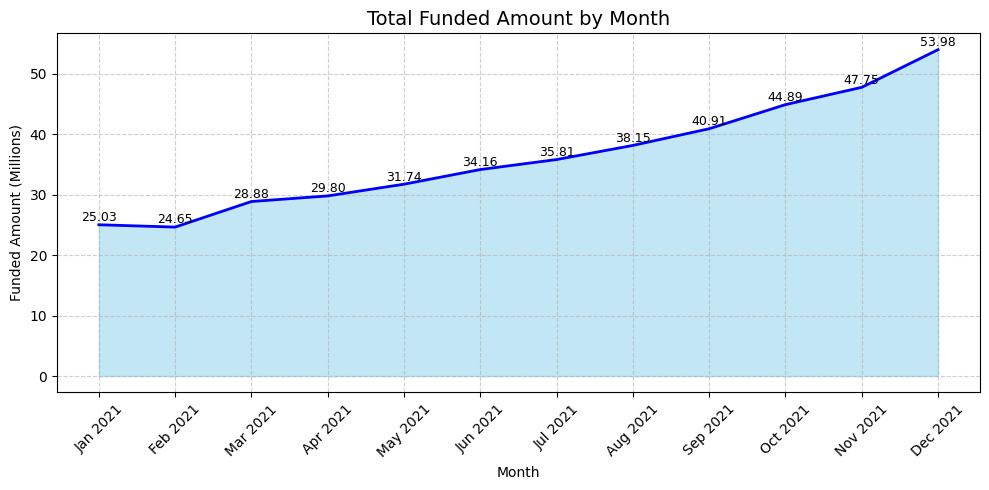

In [ ]:
monthly_funded = (
  df.sort_values('issue_date')
    .assign(month_name= lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='blue', linewidth=2)

for i, row in monthly_funded.iterrows():
  plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
          ha='center', va='bottom', fontsize=9, rotation=0, color='black')


plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show

# Time Series Area Chart (Total Received Amount by Month)

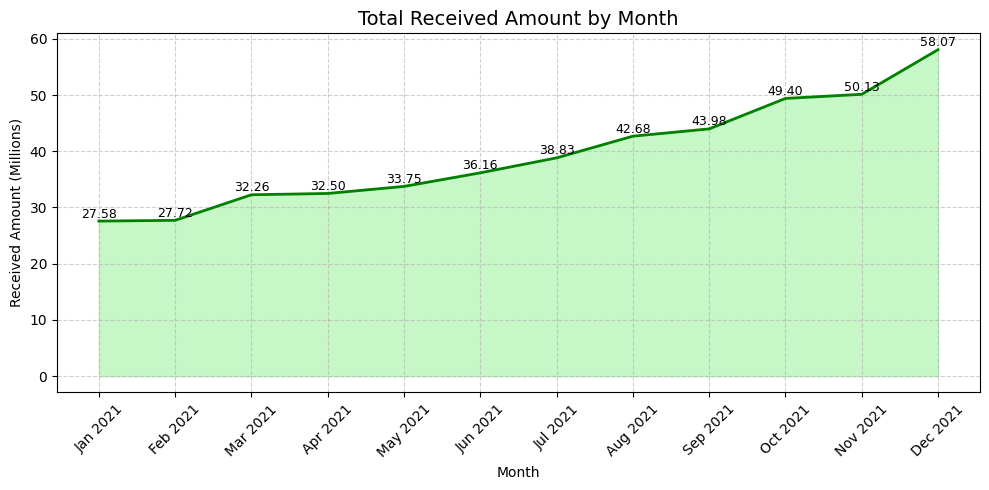

In [ ]:
monthly_received = (
  df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name= 'received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['received_amount_millions'],
                color='lightgreen', alpha=0.5)

plt.plot(monthly_received['month_name'], monthly_received['received_amount_millions'],
                color='green', linewidth=2)

for i, row in monthly_received.iterrows():
  plt.text(i, row['received_amount_millions']+ 0.1, f"{row['received_amount_millions']:.2f}",
           ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (Millions)')
plt.xticks (ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Time Series Area Chart (Total Loan Applications by Month)

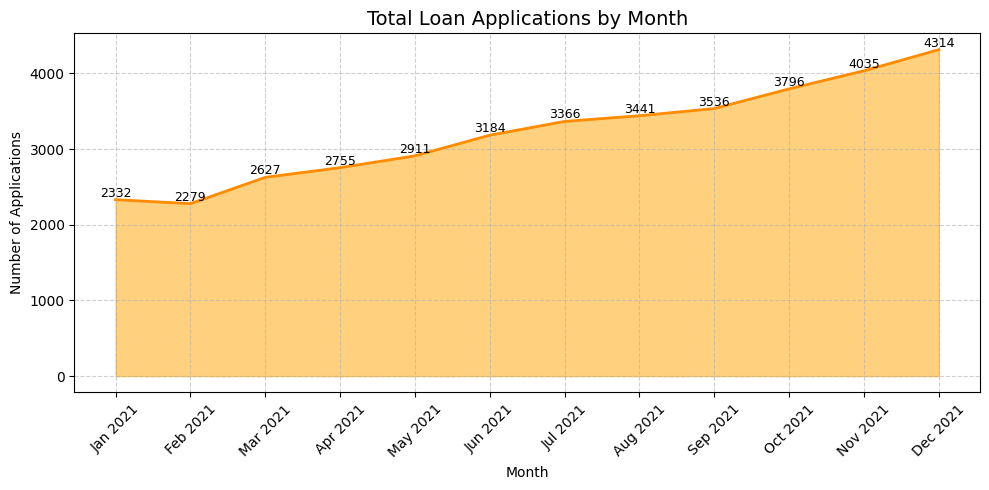

In [ ]:
monthly_applications= (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['loan_applications_count'],
                color='orange', alpha=0.5)

plt.plot(monthly_applications['month_name'], monthly_applications['loan_applications_count'],
                color='darkorange', linewidth=2)
for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.5, f"{row['loan_applications_count']}",
            ha='center', va= 'bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# US Choropleth Map (Loan Distribution & Default Rate by State)

In [ ]:
import plotly.express as px

state_data = df.groupby('address_state').agg(
    total_amount=('loan_amount', 'sum'),
    default_rate=('loan_status', lambda x: round((x == 'Charged Off').mean() * 100, 2))
).reset_index()

fig = px.choropleth(state_data,
                    locations='address_state',
                    locationmode="USA-states",
                    color='total_amount',
                    scope="usa",
                    color_continuous_scale="YlGnBu",
                    hover_data={'address_state': True, 'total_amount': ':$,.0f', 'default_rate': ':.2f%'},
                    labels={'total_amount': 'Total Funded Amount ($)', 'Charged Off Rate': 'Default Rate (%)'},
                    title='Total Loan Amount & Default Rate by US State')

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

# Pie Chart - Total Funded Amount by Term

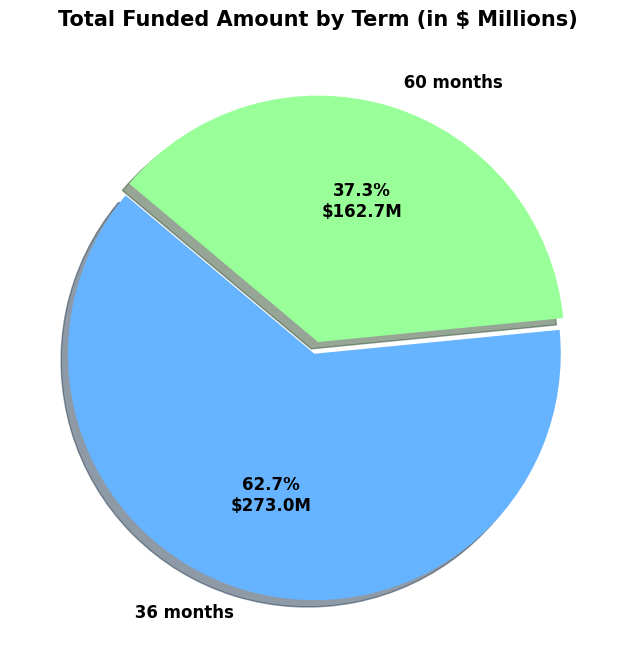

In [ ]:
#37.3% من إجمالي الأموال المُقرضة راحت لقروض 60 شهر
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(8, 8))
colors = ['#66b3ff','#99ff99']
explode = (0.05, 0)

plt.pie(term_funding_millions,
        labels=term_funding_millions.index,
        autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
        startangle=140,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title("Total Funded Amount by Term (in $ Millions)", fontsize=15, weight='bold')
plt.show()

# Horizontal Bar Chart (Total Funded Amount by Employment Length)

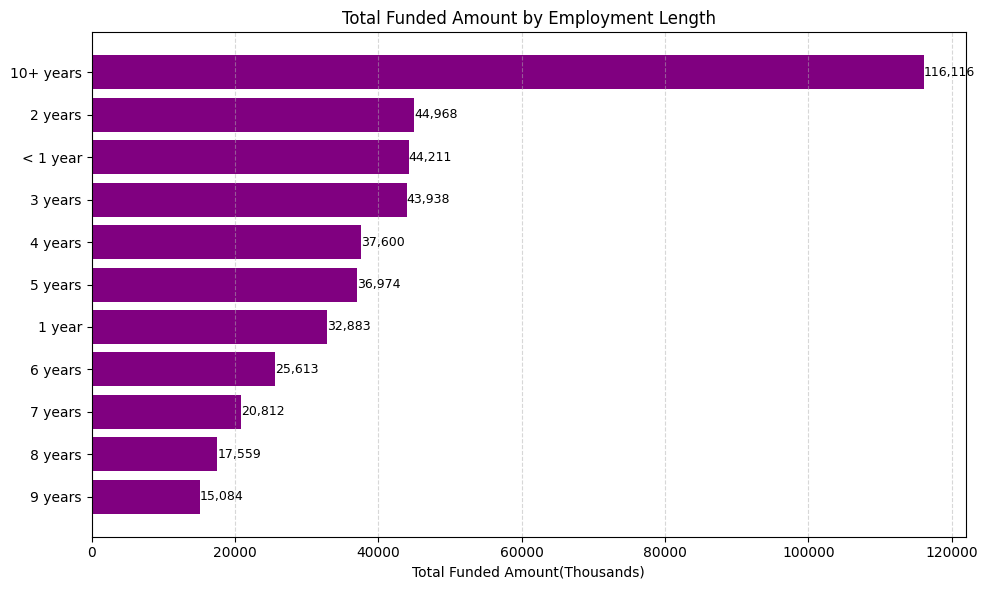

In [ ]:
emp_funding= df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10, 6))
bars =plt.barh(emp_funding.index, emp_funding, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}", va='center', fontsize=9)

plt.xlabel('Total Funded Amount(Thousands)')
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Horizontal Bar Chart (Total Funded Amount by Loan Purpose)

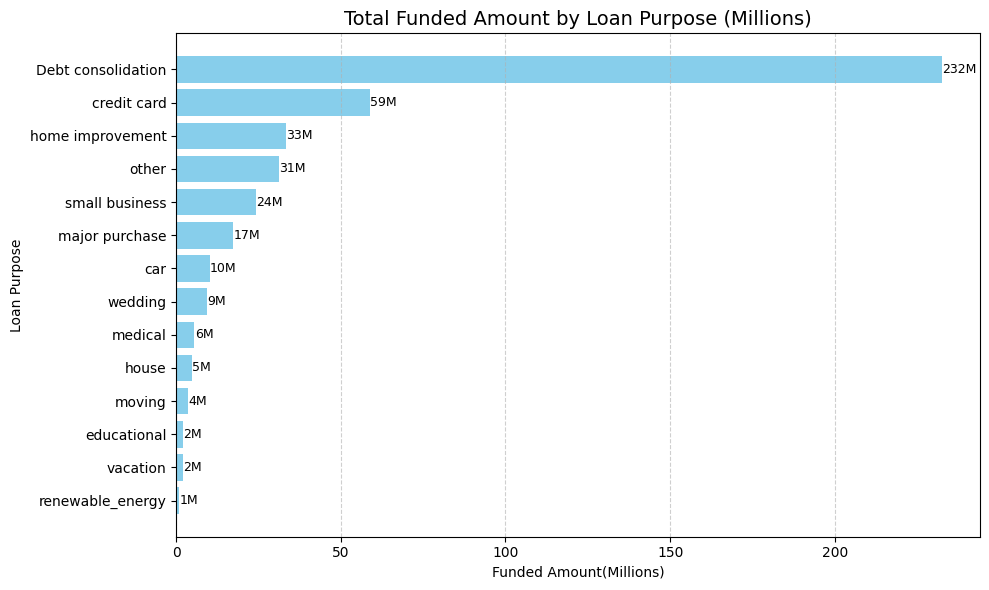

In [ ]:
purpose_funding_millions= df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000

plt.figure(figsize=(10, 6))
bars =plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
            f"{width:,.0f}M", va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose (Millions)', fontsize=14)
plt.xlabel('Funded Amount(Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Treemap - Total Funded Amount by Home Ownership

In [ ]:
home_funding= df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions']= home_funding['loan_amount']/1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='blues',
    title='Total Funded Amount by Home Ownership (Millions)'
)

fig.show()